# Notebook 5 : Attaque de reconstruction d'agrégat

L'objectif de ce notebook est de souligner l'importance des **mécanismes de protection** pour empecher la reconstruction de tout ou partie 
d'un agrégat de courbes de charges journalières.

L'adversaire observe $L_{real}\in\mathbb{R}^{48}$, connaît $D = D_{in}\cup D_{out}$ et $n=|D_{in}|$, mais pas $D_{in}$. Il cherche $D_{in}$ via

$$P^\star \in \arg\min_{P\subseteq D,\ |P|=n}\ \mathrm{dist}\!\left(\tfrac1n\textstyle\sum_{i\in P}\ell_i,\widetilde{L}\right).$$

 


In [1]:
%reload_ext autoreload
%autoreload 2
import sys, pathlib, time
ROOT = pathlib.Path.cwd().parent                  
if str(ROOT) not in sys.path:                     
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from ipywidgets import interact, IntSlider, Dropdown
from tqdm.notebook import tqdm
import time
import datetime
import os
import online_dp as dp
from online_dp.config import Config
from online_dp.cache import compute_or_load
from online_dp import data, metrics, basis, gam, mechanisms, vfast, viz
from online_dp import attack     
import umap
from ts2vec import TS2Vec
import warnings


cfg = Config(
    data_dir=str(ROOT / "data" / "DataDiffusionDeepCourboGen") + "/",   
    cache_dir=str(ROOT / "cache"),
    n_panel=500, n_target=50, seed=0,                
)
dp.cache.CACHE = pathlib.Path(cfg.cache_dir)       

## Données

In [2]:
dataset = compute_or_load(cfg.key('dataset'), lambda: data.build_dataset(cfg))
df_daily = dataset['df_daily']
n_users = df_daily.index.get_level_values('household_id').nunique()
print(f"df_daily {df_daily.shape} | foyers disponibles : {n_users}")

[cache] 'dataset__N1000_np500_nt50_s0' rechargé (joblib).
df_daily (362000, 48) | foyers disponibles : 1000


## Visualisation (time series encoder + UMAP) 

In [3]:
# sample 100 foyers 
all_households = df_daily.index.get_level_values('household_id').unique()
rng = np.random.default_rng(seed=42)
sampled_households = rng.choice(all_households, size=100, replace=False)

# Filtrer sur le 8 juillet 2023
target_date = datetime.date(2023, 7, 8)  
mask = (
    df_daily.index.get_level_values('household_id').isin(sampled_households) &
    (df_daily.index.get_level_values('date') == target_date)
)
df_day = df_daily[mask]
print(f"Profils disponibles le {target_date} : {len(df_day)}")

# Tirer D_real (50 profils) et D_decoy (complémentaire) 
df_real  = df_day.sample(n=50, replace=False, random_state=42)
df_decoy = df_day.drop(index=df_real.index)

D_real  = df_real.values   # (50, 48)
D_decoy = df_decoy.values  # (50, 48)
print(f"D_real : {D_real.shape} | D_decoy : {D_decoy.shape}")


Profils disponibles le 2023-07-08 : 100
D_real : (50, 48) | D_decoy : (50, 48)


In [7]:
# encoding des time series de conso via ts2vec 

# Hyperparamètres 
LATENT_DIM = 16
DEPTH      = 4
HIDDEN_DIM = 64
# training
EPOCHS     = 50
BATCH_SIZE = 8   

X_real  = D_real[:, :, np.newaxis].astype(np.float32)   # (50, 48, 1)
X_decoy = D_decoy[:, :, np.newaxis].astype(np.float32)  # (50, 48, 1)

X_all = np.concatenate([X_real, X_decoy], axis=0)  # (100, 48, 1)

# Entraînement
model = TS2Vec(
    input_dims=1,
    output_dims=LATENT_DIM,
    depth=DEPTH,
    hidden_dims=HIDDEN_DIM,
    batch_size=BATCH_SIZE,
    device = 'cpu'
)

model.fit(X_all, n_epochs=EPOCHS,verbose=False)

# Encoding 
Z_real  = model.encode(X_real,  encoding_window='full_series')  # (50, 16)
Z_decoy = model.encode(X_decoy, encoding_window='full_series')  # (50, 16)

print(f"Z_real  : {Z_real.shape}")
print(f"Z_decoy : {Z_decoy.shape}")


/home/G70186/.local/lib/python3.10/site-packages/torch/autograd/graph.py:882: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Z_real  : (50, 16)
Z_decoy : (50, 16)


In [8]:
# UMAP sur les embeddings 

agg_real     = D_real.mean(axis=0, keepdims=True)          # (1, 48)
X_agg        = agg_real[:, :, np.newaxis].astype(np.float32)  # (1, 48, 1)
Z_agg        = model.encode(X_agg, encoding_window='full_series')  # (1, 16)

# UMAP sur l'union + agrégat réel
Z_all_plus   = np.concatenate([Z_real, Z_decoy, Z_agg], axis=0)  # (101, 16)

reducer = umap.UMAP(n_components=2, n_neighbors=80, min_dist=0.1,
                    random_state=42)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    Z_2d = reducer.fit_transform(Z_all_plus)  # (101, 2)

Z_real_2d  = Z_2d[:50]
Z_decoy_2d = Z_2d[50:100]
Z_agg_2d   = Z_2d[100]


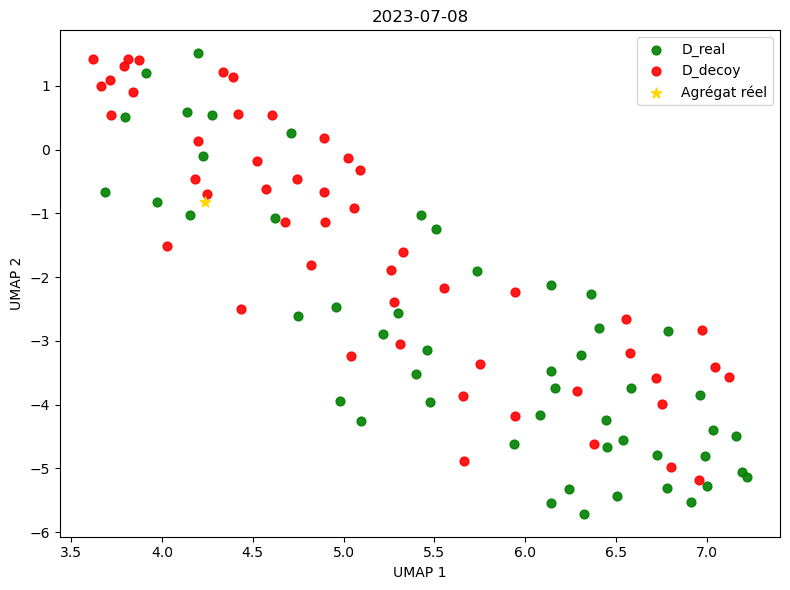

In [9]:
# Visualisation
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(*Z_real_2d.T,  label='D_real',       color='green', alpha=0.9, s=40)
ax.scatter(*Z_decoy_2d.T, label='D_decoy',      color='red',    alpha=0.9, s=40)
ax.scatter(*Z_agg_2d,     label='Agrégat réel', color='gold',      s=60,     marker='*', zorder=5)

ax.set_title(f'{target_date}')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend()
plt.tight_layout()
plt.show()

## Construction de l'instance d'attaque

In [4]:
inst = attack.build_attack_instance(df_daily, n_in=50, n_decoy=50, mode="day", seed=42)
D, in_idx, L_real, N = inst["D"], inst["in_idx"], inst["L_real"], inst["N"]
print(f"D : {D.shape} ; |D_real| = {N} ; |D| = {len(D)} ; mode = {inst['mode']}")

D : (100, 48) ; |D_real| = 50 ; |D| = 100 ; mode = day


### Attaques de reconstruction 
on convertit le problème initial en un MILP (Mixed Integer Linear Program) et on utilise un solver : scipy.milp, ortools cp-sat, gurobi ...


NB : Le **greedy swapping** donne *un* **optimum local**. La résolution avec distance $L_1$ par **MILP** propose de converger vers un **minimum global**.

### Sans projection ni bruit 

In [5]:
P_idx, dist = attack.exact_attack_l1(D, L_real, N)
inter, frac  = attack.overlap(P_idx, in_idx)
adv          = attack.advantage(frac, N, len(D))

print(f"dist L1 = {dist:.4g} | retrouvés : {inter}/{N} ({frac:.0%}) | avantage : {adv:.2f}")

dist L1 = 0 | retrouvés : 50/50 (100%) | avantage : 1.00


In [12]:
#Encodage TS2Vec + UMAP 
D_real_inst  = inst["D"][in_idx]                                   # (50, 48)
D_decoy_inst = inst["D"][np.setdiff1d(np.arange(len(D)), in_idx)] # (50, 48)

X_real_inst  = D_real_inst[:, :, np.newaxis].astype(np.float32)
X_decoy_inst = D_decoy_inst[:, :, np.newaxis].astype(np.float32)

Z_real_inst  = model.encode(X_real_inst,  encoding_window='full_series')
Z_decoy_inst = model.encode(X_decoy_inst, encoding_window='full_series')

# Agrégat réel
agg_inst     = L_real[np.newaxis, :, np.newaxis].astype(np.float32)
Z_agg_inst   = model.encode(agg_inst, encoding_window='full_series')

Z_all_inst   = np.concatenate([Z_real_inst, Z_decoy_inst, Z_agg_inst], axis=0)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    reducer_inst = umap.UMAP(n_components=2, n_neighbors=80, min_dist=0.1, random_state=42)
    Z_2d_inst    = reducer_inst.fit_transform(Z_all_inst)

Z_real_2d_inst  = Z_2d_inst[:50]
Z_decoy_2d_inst = Z_2d_inst[50:100]
Z_agg_2d_inst   = Z_2d_inst[100]

# Masques : retrouvés vs manqués
found_in_real = np.isin(in_idx, P_idx)         
missed_mask   = ~found_in_real

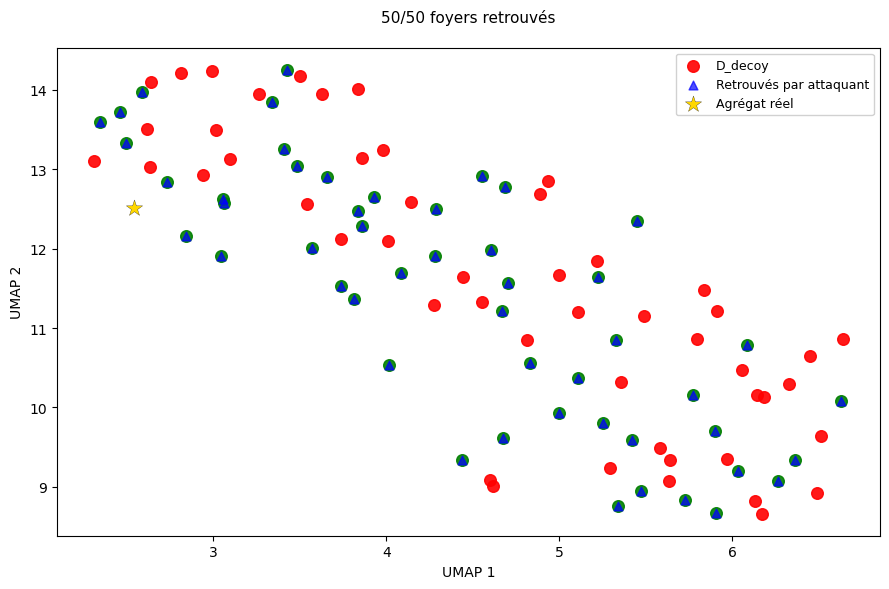

In [13]:
# Visualisation 
unique_str = "solution unique" if dist < 1e-6 else "solution non unique"
title      = (f"{inter}/{N} foyers retrouvés\n")

fig, ax = plt.subplots(figsize=(9, 6))

# D_decoy 
ax.scatter(*Z_decoy_2d_inst.T, color='red', s=70, alpha=0.9,
           label='D_decoy', zorder=1)

# D_real manqués
if missed_mask.any():
    ax.scatter(*Z_real_2d_inst[missed_mask].T, color='orange', s=70, alpha=0.85,
               label=f'D_real non retrouvés ({missed_mask.sum()})', zorder=2)

# D_real retrouvés 
if found_in_real.any():
    ax.scatter(*Z_real_2d_inst[found_in_real].T, color='green', s=70, alpha=0.9,
               zorder=3)
    ax.scatter(*Z_real_2d_inst[found_in_real].T, color='blue', s=40,
               marker='^', alpha=0.7, label=f'Retrouvés par attaquant',
               zorder=4)

# Agrégat réel
ax.scatter(*Z_agg_2d_inst, color='gold', s=150, marker='*', zorder=5,
           edgecolors='black', linewidths=0.2, label='Agrégat réel')

ax.set_title(title, fontsize=11)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(framealpha=0.9, fontsize=9)
plt.tight_layout()
fig.savefig('../figures/umap_attack_result.svg', format='svg', bbox_inches='tight')
plt.show()

### Projection sur $W$
la base d'ondelettes $W$ supposée connue par l'attaquant car calculée sur le panel public 

In [6]:
# Chargement de la base 
matched_basis = compute_or_load('matched_basis__N1000_np500_nt50_s0_agg50', lambda: None)
W = attack.load_matched_W(matched_basis, method='svd', p=10)
print(f"W shape : {W.shape}")  # (48, 10)

[cache] 'matched_basis__N1000_np500_nt50_s0_agg50' rechargé (joblib).
W shape : (48, 10)


In [7]:
#  Attaque projetée sans bruit 
res = attack.run_attack(
    inst, W,
    mode='noise',      # lance CP-SAT
    sigma=0.0,         # pas de bruit 
    time_limit=60.0,
    space='coef'
)

inter, frac = res['inter'], res['frac']
P_idx       = res['P']
found_in_real = np.isin(in_idx, P_idx)
missed_mask   = ~found_in_real

print(f"retrouvés : {inter}/{N} ({frac:.0%}) | optimal : {res['optimal']}")

retrouvés : 50/50 (100%) | optimal : False


In [16]:
# Encodage TS2Vec sur les courbes projetées 
D_real_proj  = inst['D'][in_idx]   @ W @ W.T   # (50, 48)
D_decoy_proj = inst['D'][~np.isin(np.arange(len(inst['D'])), in_idx)] @ W @ W.T  # (50, 48)
L_real_proj  = (inst['L_real'] @ W @ W.T)[np.newaxis]  # (1, 48)

X_real_proj  = D_real_proj[:, :, np.newaxis].astype(np.float32)
X_decoy_proj = D_decoy_proj[:, :, np.newaxis].astype(np.float32)
X_agg_proj   = L_real_proj[:, :, np.newaxis].astype(np.float32)

Z_real_proj  = model.encode(X_real_proj,  encoding_window='full_series')  # (50, 16)
Z_decoy_proj = model.encode(X_decoy_proj, encoding_window='full_series')  # (50, 16)
Z_agg_proj   = model.encode(X_agg_proj,   encoding_window='full_series')  # (1,  16)

# UMAP
Z_all_proj = np.concatenate([Z_real_proj, Z_decoy_proj, Z_agg_proj], axis=0)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    Z_2d_proj = umap.UMAP(n_components=2, n_neighbors=80, min_dist=0.1,
                          random_state=42).fit_transform(Z_all_proj)

Z_real_2d_proj  = Z_2d_proj[:50]
Z_decoy_2d_proj = Z_2d_proj[50:100]
Z_agg_2d_proj   = Z_2d_proj[100]

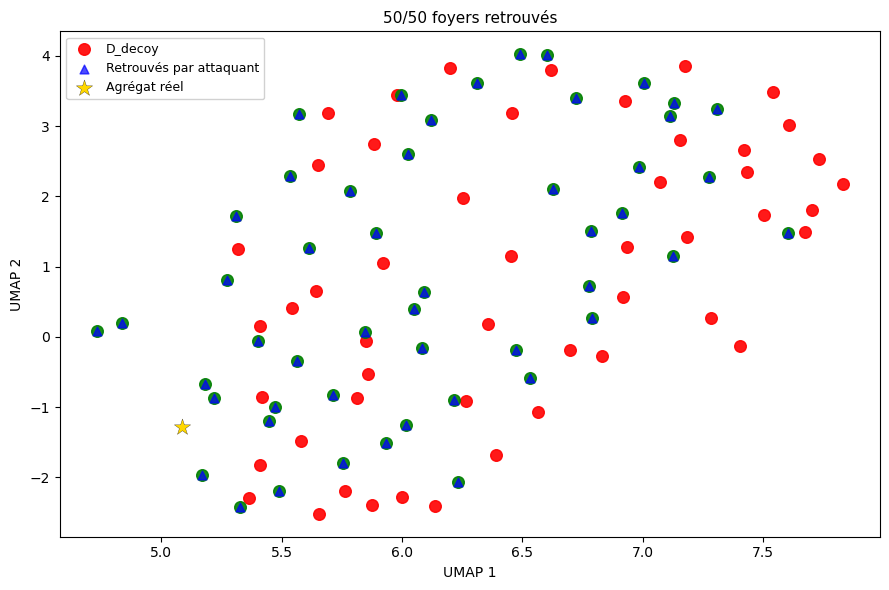

In [17]:
# Masques retrouvés / manqués 
P_idx         = res['P']
found_in_real = np.isin(in_idx, P_idx)
missed_mask   = ~found_in_real
inter         = found_in_real.sum()

# Visualisation 
optimal_str = "solution optimale certifiée" if res['optimal'] else "best-so-far (non certifié)"
title = (f"{inter}/{N} foyers retrouvés")

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(*Z_decoy_2d_proj.T, color='red', s=70, alpha=0.9,
           label='D_decoy', zorder=1)

if missed_mask.any():
    ax.scatter(*Z_real_2d_proj[missed_mask].T, color='orange', s=70, alpha=0.85,
               label=f'D_real non retrouvés ({missed_mask.sum()})', zorder=2)

if found_in_real.any():
    ax.scatter(*Z_real_2d_proj[found_in_real].T, color='green', s=70, alpha=0.9,
               zorder=3)
    ax.scatter(*Z_real_2d_proj[found_in_real].T, color='blue', s=40,
               marker='^', alpha=0.7, label='Retrouvés par attaquant', zorder=4)

ax.scatter(*Z_agg_2d_proj, color='gold', s=150, marker='*', zorder=5,
           edgecolors='black', linewidths=0.2, label='Agrégat réel')

ax.set_title(title, fontsize=11)
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(framealpha=0.9, fontsize=9)
plt.tight_layout()
plt.show()

### Projection sur $W$ + Bruit 

In [11]:
#  Paramètres 
EPS_GRID = np.array([0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0])
N_SEEDS  = 50        # nb tirages 
DELTA    = 1e-5
SPACE    = 'coef'
TLIM     = 30.0      # budget solver par run

#  Sensibilité L2 
from online_dp.mechanisms import sigma_one_release
from online_dp.basis      import panel_sensitivity_l2
clip_C, Delta2 = panel_sensitivity_l2(inst['D'], W, n_target=N)
print(f"clip_C = {clip_C:.4g} | Delta2 = {Delta2:.4g}")

#  Clé de cache — fingerprinte l'instance (ordre des ids), W, et tous les hyperparamètres 
import hashlib
inst_fp = hashlib.md5(str(list(inst['ids'])).encode()).hexdigest()[:8]
W_fp    = hashlib.md5(np.round(W, 6).tobytes()).hexdigest()[:8]
eps_tag = "-".join(f"{e:g}" for e in EPS_GRID)
KEY = cfg.key('attack_freq_roc',
              inst=inst_fp, W=W_fp, mode=inst['mode'], N=N, M=len(inst['D']),
              eps=eps_tag, K=N_SEEDS, delta=DELTA, tlim=TLIM, space=SPACE)
print(KEY)

#  Balayage log × seeds — enrobe dans une fonction, appelée seulement si absente du cache 
def _run_attack_grid():
    records = []
    P_by_eps = {float(eps): [] for eps in EPS_GRID}   #  P_idx
    pbar    = tqdm(total=len(EPS_GRID) * N_SEEDS,
                   desc="Attaque WPA (grid log × seeds)", unit="run")
    for eps in EPS_GRID:
        sigma, _ = sigma_one_release(eps, DELTA, Delta2)
        for seed in range(N_SEEDS):
            t0 = time.perf_counter()
            r  = attack.run_attack(
                inst, W,
                mode='noise', sigma=sigma, clip_C=clip_C, Delta2=Delta2,
                seed=seed, space=SPACE, time_limit=TLIM
            )
            dt = time.perf_counter() - t0
            records.append(dict(eps=float(eps), sigma=float(sigma), seed=int(seed),
                                frac=r['frac'], inter=r['inter'],
                                optimal=r['optimal'], dt_s=dt))
            P_by_eps[float(eps)].append(np.asarray(r['P'], int))
            pbar.set_postfix(eps=f"{eps:.2g}", σ=f"{sigma:.2g}",
                             frac=f"{r['frac']:.0%}", s=seed)
            pbar.update(1)
    pbar.close()
    return dict(records=records, P_by_eps=P_by_eps)


result   = compute_or_load(KEY, _run_attack_grid)
records  = result['records']
P_by_eps = result['P_by_eps']
df_raw   = pd.DataFrame(records)

# Statistiques par eps
df_stats = (
    df_raw.groupby('eps')['frac']
    .agg(
        mean   = 'mean',
        q05    = lambda x: np.quantile(x, 0.05),
        q25    = lambda x: np.quantile(x, 0.25),
        q75    = lambda x: np.quantile(x, 0.75),
        q95    = lambda x: np.quantile(x, 0.95),
        sigma  = lambda x: df_raw.loc[x.index, 'sigma'].iloc[0],
    )
    .reset_index()
)
df_stats[['mean','q05','q25','q75','q95']] *= 100   
print(df_stats[['eps','sigma','mean','q05','q25','q75','q95']].to_string(index=False))

clip_C = 18.78 | Delta2 = 0.3756
attack_freq_roc__N1000_np500_nt50_s0_inst1a311e0f_Wc56e4c40_modeday_N50_M100_eps0.001-0.01-0.1-1-10-100-1000-10000_K50_delta1e-05_tlim30.0_spacecoef
[cache] 'attack_freq_roc__N1000_np500_nt50_s0_inst1a311e0f_Wc56e4c40_modeday_N50_M100_eps0.001-0.01-0.1-1-10-100-1000-10000_K50_delta1e-05_tlim30.0_spacecoef' rechargé (joblib).
      eps       sigma  mean  q05  q25   q75   q95
    0.001 1802.331382 50.16 42.9 46.0  54.0  60.0
    0.010  180.268352 50.12 42.0 46.0  54.0  60.0
    0.100   18.061974 50.16 42.9 46.0  54.0  59.1
    1.000    1.840614 50.64 42.0 48.0  54.0  58.0
   10.000    0.213298 55.56 46.9 52.5  58.0  63.1
  100.000    0.037057 61.40 52.0 56.0  64.0  81.1
 1000.000    0.009348 69.28 50.0 54.0  91.5 100.0
10000.000    0.002747 94.16 54.0 98.5 100.0 100.0


# Confusion matrices

In [12]:
KEY = ("attack_freq_roc__N1000_np500_nt50_s0_inst1a311e0f_Wc56e4c40_modeday_"
       "N50_M100_eps0.001-0.01-0.1-1-10-100-1000-10000_K50_delta1e-05_tlim30.0_spacecoef")

result   = compute_or_load(KEY, _run_attack_grid)   # cache hit -> instantane
P_by_eps = result['P_by_eps']
M = len(inst['D'])

def confusion_matrix_topn(p_hat, in_idx, M, N):
    """
    Matrice de confusion au seuillage top-N : les N foyers de plus grand p_hat
    sont predits dans D_in.
    """
    in_idx = np.asarray(in_idx, int)
    y_true = np.zeros(M, dtype=int); y_true[in_idx] = 1
    order = np.argsort(-p_hat, kind='stable')
    pred = np.zeros(M, dtype=int)
    pred[order[:N]] = 1
    tp = int(((pred == 1) & (y_true == 1)).sum())
    fp = int(((pred == 1) & (y_true == 0)).sum())
    fn = int(((pred == 0) & (y_true == 1)).sum())
    tn = int(((pred == 0) & (y_true == 0)).sum())
    C = np.array([[tn, fp],
                  [fn, tp]])
    return dict(tp=tp, fp=fp, fn=fn, tn=tn, C=C)

conf_by_eps = {}
for eps in EPS_GRID:
    p_hat = attack.selection_frequency(P_by_eps[float(eps)], M)
    conf_by_eps[float(eps)] = confusion_matrix_topn(p_hat, inst['in_idx'], M, N)

print(f"{'eps':>10} | {'TP':>3} {'FP':>3} {'FN':>3} {'TN':>3} | accuracy")
for eps in EPS_GRID:
    c = conf_by_eps[float(eps)]
    acc = (c['tp'] + c['tn']) / M
    print(f"{eps:10.4g} | {c['tp']:3d} {c['fp']:3d} {c['fn']:3d} {c['tn']:3d} | {acc:.3f}")

[cache] 'attack_freq_roc__N1000_np500_nt50_s0_inst1a311e0f_Wc56e4c40_modeday_N50_M100_eps0.001-0.01-0.1-1-10-100-1000-10000_K50_delta1e-05_tlim30.0_spacecoef' rechargé (joblib).
       eps |  TP  FP  FN  TN | accuracy
     0.001 |  31  19  19  31 | 0.620
      0.01 |  30  20  20  30 | 0.600
       0.1 |  28  22  22  28 | 0.560
         1 |  27  23  23  27 | 0.540
        10 |  33  17  17  33 | 0.660
       100 |  37  13  13  37 | 0.740
      1000 |  48   2   2  48 | 0.960
     1e+04 |  50   0   0  50 | 1.000


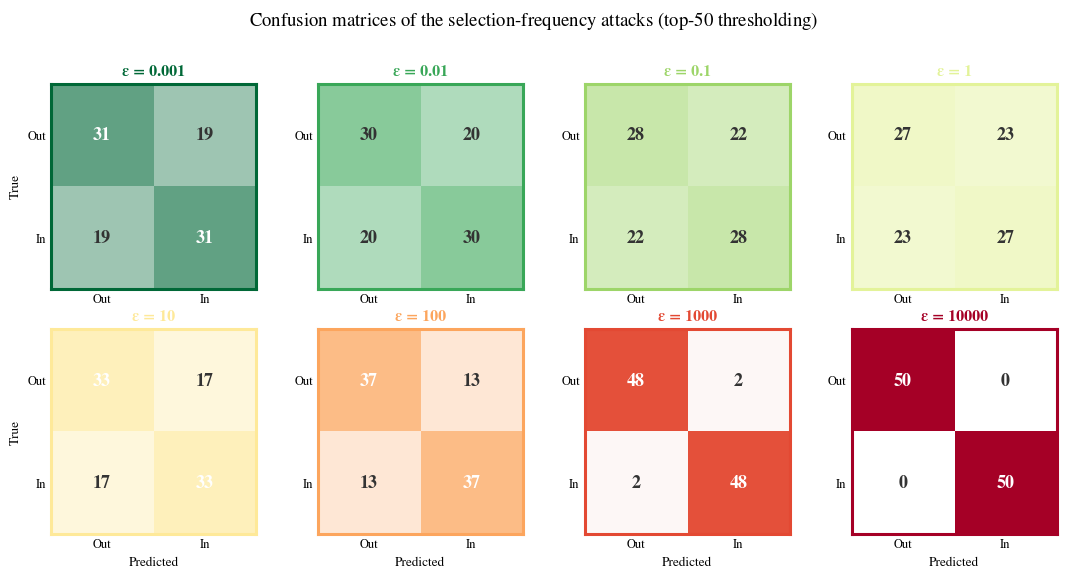

In [13]:
import matplotlib as mpl
from matplotlib.colors import LogNorm, LinearSegmentedColormap

mpl.rcParams['font.family']      = 'STIXGeneral'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['axes.linewidth']   = 0.8

cmap_base = plt.cm.RdYlGn_r
norm = LogNorm(vmin=EPS_GRID.min(), vmax=EPS_GRID.max())

fig, axes = plt.subplots(2, 4, figsize=(11, 5.6))
labels = ['Out', 'In']

for ax, eps in zip(axes.flat, EPS_GRID):
    c = conf_by_eps[float(eps)]
    eps_color = cmap_base(norm(eps))
    cmap_panel = LinearSegmentedColormap.from_list('panel', ['white', eps_color])

    ax.imshow(c['C'], cmap=cmap_panel, vmin=0, vmax=N, aspect='equal')

    for i in range(2):
        for j in range(2):
            val = c['C'][i, j]
            txt_color = 'white' if val > 0.6 * N else '#333333'
            ax.text(j, i, str(val), ha='center', va='center',
                     fontsize=13, color=txt_color, fontweight='bold')

    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_color(eps_color); spine.set_linewidth(2.2)

    ax.set_title(f"\u03b5 = {eps:g}", fontsize=11.5, color=eps_color, fontweight='bold', pad=6)

for ax in axes[1, :]:
    ax.set_xlabel('Predicted', fontsize=9.5)
for ax in axes[:, 0]:
    ax.set_ylabel('True', fontsize=9.5)

fig.suptitle('Confusion matrices of the selection-frequency attacks (top-$50$ thresholding)',
             fontsize=13.5, y=1.015)
plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/confmat_grid.png', bbox_inches='tight', facecolor='white')
plt.show()

## Matrice de confusion pour l'attaque aléatoire avec quantification d'incertitude 

K utilisé : 1000
[[25.421 24.579]
 [24.579 25.421]] 
 [[2.53696575 2.53696575]
 [2.53696575 2.53696575]]


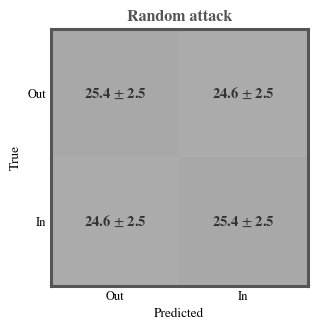

in_idx triés (extrait) : [0 1 2 3 4 5 6 7 8 9] ...


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

M      = len(inst['D'])                        # 2n candidats
in_idx = np.asarray(inst['in_idx'], int)       # indices des foyers réellement In
K      = 1000    # même K que les attaques réelles
B      = 1000
rng    = np.random.default_rng(0)

def random_attack_pipeline(rng):
    """K sélections uniformes de N parmi M -> p_hat -> ton seuillage top-N."""
    p_hat = np.zeros(M)
    for _ in range(K):
        p_hat[rng.choice(M, size=N, replace=False)] += 1.0 / K
    return confusion_matrix_topn(p_hat, in_idx, M, N)['C']

C_rand = np.array([random_attack_pipeline(rng) for _ in range(B)], dtype=float)
C_mean = C_rand.mean(axis=0)
C_std  = C_rand.std(axis=0, ddof=1)
print("K utilisé :", K)
print(C_mean, '\n', C_std)                     # attendu si tout va bien : ~25 ± 2.5

# --- figure (palette grise) ---
gray      = '#555555'
cmap_gray = LinearSegmentedColormap.from_list('gray_panel', ['white', gray])
fig, ax = plt.subplots(figsize=(3.4, 3.4))
ax.imshow(C_mean, cmap=cmap_gray, vmin=0, vmax=N, aspect='equal')
for i in range(2):
    for j in range(2):
        m, s = C_mean[i, j], C_std[i, j]
        txt_color = 'white' if m > 0.6 * N else '#333333'
        ax.text(j, i, f"{m:.1f} $\\pm$ {s:.1f}", ha='center', va='center',
                fontsize=10.5, color=txt_color, fontweight='bold')
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(['Out', 'In'], fontsize=9); ax.set_yticklabels(['Out', 'In'], fontsize=9)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(True); spine.set_color(gray); spine.set_linewidth(2.2)
ax.set_xlabel('Predicted', fontsize=9.5); ax.set_ylabel('True', fontsize=9.5)
ax.set_title('Random attack', fontsize=11.5, color=gray, fontweight='bold', pad=6)
plt.tight_layout()
fig.savefig('../figures/confmat_random.png', bbox_inches='tight', facecolor='white', dpi=200)
plt.show()
# --- diagnostic du bris d'égalité (voir point 1 ci-dessous) ---
print("in_idx triés (extrait) :", np.sort(in_idx)[:10], "...")

## Courbes ROC pour différentes valeurs de $\varepsilon$ 

[cache] 'attack_random_baseline__M100_N50_K100_seed0' rechargé (joblib).


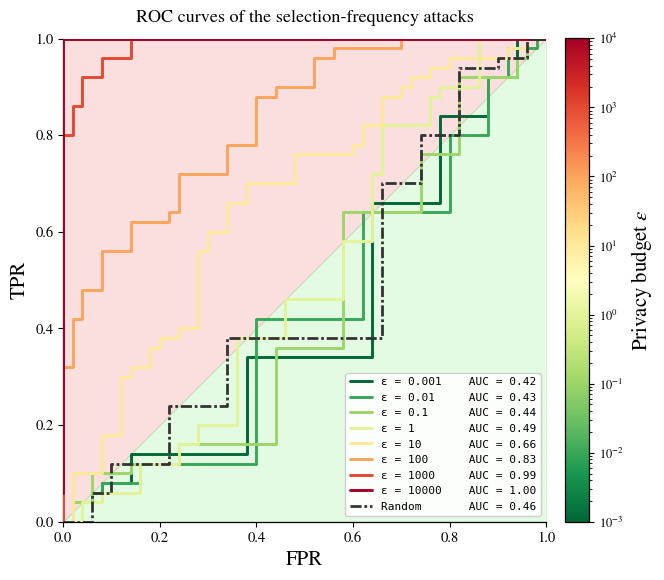

In [17]:
def auc_escalier(fpr, tpr, drawstyle='steps-post'):
    fpr = np.asarray(fpr, float); tpr = np.asarray(tpr, float)
    if drawstyle == 'steps-post':
        return float(np.sum((fpr[1:] - fpr[:-1]) * tpr[:-1]))
    elif drawstyle == 'steps-pre':
        return float(np.sum((fpr[1:] - fpr[:-1]) * tpr[1:]))
    raise ValueError(drawstyle)

# ROC 
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

M = len(inst['D'])
N_TAU = 50  

roc_by_eps = {}
for eps in EPS_GRID:
    p_hat = attack.selection_frequency(P_by_eps[float(eps)], M)
    roc_by_eps[float(eps)] = dict(
        p_hat=p_hat,
        **attack.roc_from_scores_grid(p_hat, inst['in_idx'], M, n_tau=N_TAU)
    )

#  baseline aleatoire : K tirages uniformes de N foyers parmi M
K_RANDOM = 100
KEY_random = f"attack_random_baseline__M{M}_N{N}_K{K_RANDOM}_seed0"

def _run_random_baseline():
    rng = np.random.default_rng(0)
    P_list = [rng.choice(M, size=N, replace=False).astype(int) for _ in range(K_RANDOM)]
    return dict(P_list=P_list)

result_random = compute_or_load(KEY_random, _run_random_baseline)
p_hat_random = attack.selection_frequency(result_random['P_list'], M)
roc_random = attack.roc_from_scores_grid(p_hat_random, inst['in_idx'], M, n_tau=N_TAU)
auc_random = auc_escalier(roc_random['fpr'], roc_random['tpr'], drawstyle='steps-post')

mpl.rcParams['font.family']      = 'STIXGeneral'
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['axes.linewidth']   = 0.9
mpl.rcParams['font.size']        = 12

fig, ax = plt.subplots(figsize=(6.8, 6.4))
ax.fill_between([0, 1], [0, 1], [1, 1], color='lightcoral', alpha=0.25, zorder=0)
ax.fill_between([0, 1], [0, 0], [0, 1], color='lightgreen', alpha=0.25, zorder=0)

cmap = plt.cm.RdYlGn_r
norm = LogNorm(vmin=EPS_GRID.min(), vmax=EPS_GRID.max())

for eps in EPS_GRID:
    r = roc_by_eps[float(eps)]
    auc_val = auc_escalier(r['fpr'], r['tpr'], drawstyle='steps-post')
    label = f"\u03b5 = {eps:<9g}AUC = {auc_val:.2f}"
    ax.plot(r['fpr'], r['tpr'], drawstyle='steps-post',
             color=cmap(norm(eps)), lw=2.1, solid_capstyle='round', zorder=3,
             label=label)

# baseline aleatoire 
label_random = f"{'Random':<13s}AUC = {auc_random:.2f}"
ax.plot(roc_random['fpr'], roc_random['tpr'], drawstyle='steps-post',
        color='#333333', lw=2.0, ls=(0, (4, 1, 1, 1)), solid_capstyle='round',
        zorder=4, label=label_random)

sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.035)
cbar.set_label(r'Privacy budget $\varepsilon$', fontsize=15)
cbar.ax.tick_params(labelsize=9)

ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_xlabel('FPR', fontsize=15)
ax.set_ylabel('TPR', fontsize=15)
ax.set_title('ROC curves of the selection-frequency attacks', fontsize=13, pad=12)
ax.set_aspect('equal')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(labelsize=10.5)
ax.legend(loc='lower right', framealpha=0.92, edgecolor='#cccccc',
          prop={'family': 'monospace', 'size': 8.0})

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/roc_attaque.png', bbox_inches='tight', facecolor='white')
plt.show()

Baseline hasard  —  E[F] = 50.0%
IQR  : [46.0%, 54.0%]
IC90 : [42.0%, 58.0%]


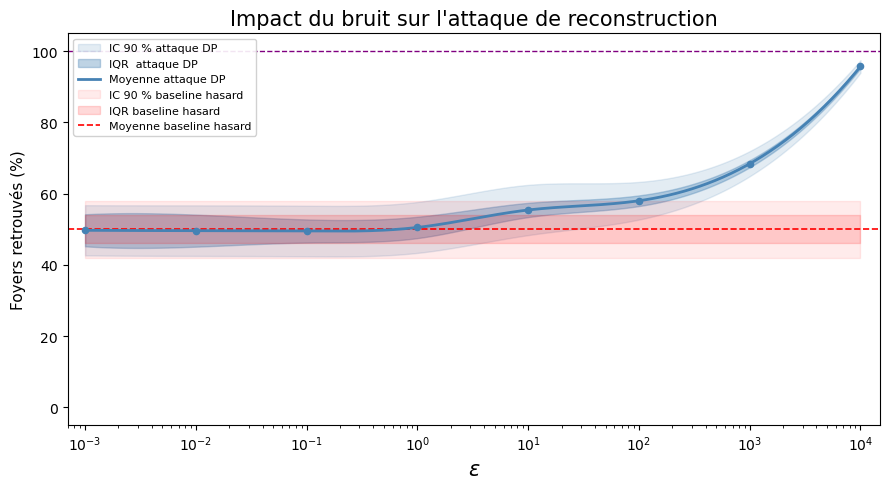

In [20]:
from scipy.stats import hypergeom
from scipy.interpolate import make_interp_spline
import numpy as np

#  Distribution exacte de la baseline hasard
# X ~ Hypergeom(M=2n, n_succ=n, N_draws=n)
n_in    = N                   # 50
n_total = len(inst['D'])      # 100
rv      = hypergeom(M=n_total, n=n_in, N=n_in)

# Quantiles analytiques exacts (en %)
base_mean = rv.mean()       / n_in * 100   
base_q05  = rv.ppf(0.05)   / n_in * 100
base_q25  = rv.ppf(0.25)   / n_in * 100
base_q75  = rv.ppf(0.75)   / n_in * 100
base_q95  = rv.ppf(0.95)   / n_in * 100

print(f"Baseline hasard  —  E[F] = {base_mean:.1f}%")
print(f"IQR  : [{base_q25:.1f}%, {base_q75:.1f}%]")
print(f"IC90 : [{base_q05:.1f}%, {base_q95:.1f}%]")

# Splines de l'attaque DP
log_eps        = np.log10(df_stats['eps'].values)
log_eps_smooth = np.linspace(log_eps.min(), log_eps.max(), 300)
eps_smooth     = 10**log_eps_smooth

def spline_smooth(y):
    spl = make_interp_spline(log_eps, y, k=3)
    return np.clip(spl(log_eps_smooth), 0, None)

mean_s = np.clip(spline_smooth(df_stats['mean'].values), 0, 100)

iqr_raw = 0.5 * (df_stats['q75'].values - df_stats['q25'].values)
ic_raw  = 0.5 * (df_stats['q95'].values - df_stats['q05'].values)
idx_ref   = np.searchsorted(df_stats['eps'].values, 10.0)
iqr_fixed = iqr_raw.copy()
ic_fixed  = ic_raw.copy()
for i in range(idx_ref + 1, len(df_stats)):
    alpha        = (i - idx_ref) / (len(df_stats) - idx_ref)
    iqr_fixed[i] = iqr_raw[idx_ref] * (1 - alpha)
    ic_fixed[i]  = ic_raw[idx_ref]  * (1 - alpha)

iqr_s = spline_smooth(iqr_fixed)
ic_s  = spline_smooth(ic_fixed)

q25_s = np.clip(mean_s - iqr_s, 0, 100)
q75_s = np.clip(mean_s + iqr_s, 0, 100)
q05_s = np.clip(mean_s - ic_s,  0, 100)
q95_s = np.clip(mean_s + ic_s,  0, 100)

# Figure 
fig, ax = plt.subplots(figsize=(9, 5))

# Attaque DP
ax.fill_between(eps_smooth, q05_s, q95_s,
                alpha=0.15, color='steelblue', label='IC 90 % attaque DP')
ax.fill_between(eps_smooth, q25_s, q75_s,
                alpha=0.35, color='steelblue', label='IQR  attaque DP')
ax.plot(eps_smooth, mean_s,
        color='steelblue', lw=2.0, zorder=4, label='Moyenne attaque DP')
ax.scatter(df_stats['eps'], df_stats['mean'],
           color='steelblue', s=20, zorder=5)

# Baseline hasard bande IC 90% (analytique)
ax.fill_between(eps_smooth,
                base_q05, base_q95,
                alpha=0.08, color='red',
                label=f'IC 90 % baseline hasard')
# Baseline hasard  IQR (analytique)
ax.fill_between(eps_smooth,
                base_q25, base_q75,
                alpha=0.15, color='red',
                label=f'IQR baseline hasard')
# Baseline hasard moyenne
ax.axhline(base_mean, color='red', lw=1.2, ls='--',
           label=f'Moyenne baseline hasard')

ax.axhline(100, color='purple', lw=1.0, ls='--')

ax.set_xscale('log')
ax.set_xlim(EPS_GRID[0] * 0.7, EPS_GRID[-1] * 1.5)
ax.set_ylim(-5, 105)
ax.set_xlabel(r'$\varepsilon$', fontsize=15)
ax.set_ylabel('Foyers retrouvés (%)', fontsize=11)
ax.set_title("Impact du bruit sur l'attaque de reconstruction", fontsize=15)
ax.legend(framealpha=0.9, fontsize=8, loc='upper left')
ax.grid(False)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/recovery_curve.svg', format='svg', bbox_inches='tight')
plt.show()